# (b)

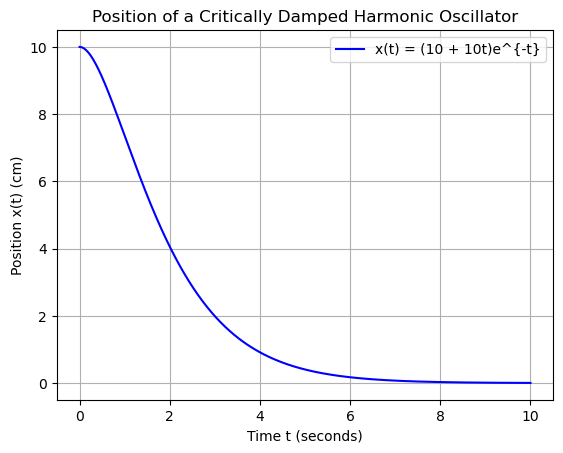

In [9]:
import numpy as np
import matplotlib.pyplot as plt

m = 1.0  
b = 2.0 

def x_analytical(t, m, b):
    return (10 + (5 * b / m) * t) * np.exp(-(b / (2 * m)) * t)

t_start = 0
t_end = 10
t_values = np.linspace(t_start, t_end, 500)

x_values = x_analytical(t_values, m, b)

plt.plot(t_values, x_values, label=r'x(t) = (10 + 10t)e^{-t}', color='blue')

plt.title('Position of a Critically Damped Harmonic Oscillator')
plt.xlabel('Time t (seconds)')
plt.ylabel('Position x(t) (cm)')
plt.grid() 
plt.legend()
plt.show() 

# (c)

In [23]:
def euler_method(f, x0_vector, t0, dt, num_step):

    t = [t0]
    x_states = [np.array(x0_vector)]

    t_1 = t0
    x_1 = np.array(x0_vector)

    for _ in range(num_step):
        dx_dt = f(t_1, x_1)
        x_2 = x_1 + dt*dx_dt
        t_2 = t_1 + dt

        t.append(t_2)
        x_states.append(x_2)

        t_1 = t_2
        x_1 = x_2
        
    return t,x_states

def damped_oscillator(t, state):
    x = state[0]
    v = state[1]
    b = 2.0
    m = 1.0
    k = 1.0
    dxdt = v
    dvdt = (-b/m)*v - (k/m)*x
    return np.array([dxdt,dvdt])

x0_position = 10.0
x0_velocity = 0.0
state_vector = np.array([x0_position, x0_velocity])
t0 = 0.0
total_time = 0.2
num_step = 500

dt = total_time/ num_step
time_values, state_vectors = euler_method(damped_oscillator, state_vector, t0, dt, num_step)

position_values = [state[0] for state in state_vectors]
velocity_values = [state[1] for state in state_vectors]

print(f"\nPosition at t={time_values[-1]:.2f}s (last step): {position_values[-1]:.4f} cm")
print(f"Velocity at t={time_values[-1]:.2f}s (last step): {velocity_values[-1]:.4f} cm/s")


Position at t=0.20s (last step): 9.8250 cm
Velocity at t=0.20s (last step): -1.6381 cm/s
